# 05 — Strategy: top-1% selective entry + let-winners-run

**One sentence.** At every 1-min boundary, open a small long BTC lot iff the
model's probability is in the **top 1% of the training distribution** (P_99).
Each lot holds an exit policy that *skips* the static +phi take-profit while
the model's conviction at the current bar is still **>= P_99**, and closes
at market the first time conviction drops below P_99 *while* the position is
in the TP zone. Positions that fall back below TP zone wait (never released
into loss).

**Winning spec — derived from the strategy-variants sweep** (`scripts/run_strategy_variants.py`):

- **P1 selectivity**: TOP_Q = 0.99 (was 0.95; +18pp total return, 11× DD reduction)
- **P3 let-winners-run**: exit at market when `p_t < P_99` AND position in TP zone
- **P2 features**: long-horizon lag + excursion windows added (4-10 day context)
- **No SL**: "don't release into loss" — losing positions wait, never auto-closed

**Differences vs. boundary-cadence v1**

- **Cadence**: 1-min. Trades land in the same minute the model fires.
- **Label–execution alignment**: barrier source `"high"`.
- **Selective entry**: single gate on top-1% training score (epistemic gate
  is in the side-sweep only).

**Production discipline**

- P_99 derived from training slice only; val/test never observed.
- Simulator runs val + test as one chronological stream.
- TP signal uses bar high; let-winners-run closes at bar.close when conviction drops.
- **Never closes at a loss**: no SL, no bulk-close, no time-based expiry. The
  only exit is conviction-drop while in the TP zone.

In [1]:
from __future__ import annotations

import json
import sys
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.gridspec as gridspec
import seaborn as sns

ROOT = Path.cwd()
if not (ROOT / "docs" / "MINIMAL_PROJECT_SPEC_v2.md").exists():
    if (ROOT.parent / "docs" / "MINIMAL_PROJECT_SPEC_v2.md").exists():
        ROOT = ROOT.parent
    else:
        raise RuntimeError("Could not locate repo root")
sys.path.insert(0, str(ROOT))

from src import utils
from src.analytics.thresholds import (
    derive_conditional_unc_cap,
    derive_top_q_threshold,
    summarize_gate_overlap,
)
from src.strategy.baseline import (
    COST_PER_TRADE,
    compute_btc_buy_and_hold,
)
from src.features.config import M as M_CFG, PHI as PHI_CFG
from src.strategy.cache import (
    augment_cache_with_boundary_ohlc,
    augment_cache_with_r_realized,
)
from src.strategy.policy import (
    RiskConfig,
    State,
    StrategySpec,
    exit_tp_or_expiry,
    gate_knowledge_unc_cap,
    gate_score_above,
    make_exit_let_winners_run,
    score_raw_p,
    size_clip,
    size_constant,
)
from src.strategy.simulator import SimConfig, simulate

DATASET_DIR = ROOT / "data" / "model_dataset"
CACHE_PATH = DATASET_DIR / "research_predictions_1min.parquet"
RAW_PATH = ROOT / "data" / "raw_data" / "klines_1m.parquet"
TRAIN_ART_PATH = DATASET_DIR / "analytics" / "train_scores_unc_1min.parquet"
VAL_TEST_ART_PATH = DATASET_DIR / "analytics" / "val_test_ve_unc_1min.parquet"
OUT_DIR = DATASET_DIR / "strategy" / "production_1min_P1P3"
OUT_DIR.mkdir(parents=True, exist_ok=True)

sns.set_style("whitegrid")
warnings.filterwarnings("ignore", category=UserWarning)
plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 160,
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.titleweight": "bold",
    "axes.labelsize": 9,
    "legend.fontsize": 8,
    "axes.grid": True,
    "grid.alpha": 0.25,
})
M = int(M_CFG)
PHI = float(PHI_CFG)
print(f"ROOT        : {ROOT}")
print(f"M, PHI      : {M}, {PHI}")
print(f"OUT_DIR     : {OUT_DIR}")


ROOT        : C:\Users\vitil\OneDrive\Desktop\barrier_classifier
M, PHI      : 20, 0.0025
OUT_DIR     : C:\Users\vitil\OneDrive\Desktop\barrier_classifier\data\model_dataset\strategy\production_1min_P1P3


## 1. Frozen-from-training threshold

Single knob, frozen on the training slice:

- `P_TH` = 99th percentile of training-period scores → top-1% entry gate AND
  let-winners-run hold threshold.

The epistemic gate is disabled in the main run (the model's `knowledge_unc`
distribution is near-zero everywhere, so the cap is non-discriminating). It
is exercised in the section-9 sweep for sensitivity.

In [2]:
TOP_Q = 0.99          # score gate AND let-winners-run hold threshold: top 1% of training p
UNC_Q_COND = 0.50     # epistemic gate quantile (used by section-9 sweep only; main run disables the gate below)
ENABLE_UNC_GATE = False  # set True to re-enable; False -> U_cap = +inf so every score-passing row fires
LOT_SIZE = 0.02       # 2% of capital per lot
MAX_CONCURRENT = 50   # 50 * 0.02 = 100% gross cap
COST = COST_PER_TRADE  # 5 bp round-trip (canonical from src.strategy.baseline)
MAX_HORIZON_BOUNDARIES = 1_000_000   # effectively no time-based expiry

train_art = pd.read_parquet(TRAIN_ART_PATH)
p_train = train_art['p_train'].to_numpy()
unc_train = train_art['knowledge_unc_train'].to_numpy()
print(f"Training slice loaded: {len(train_art):,} rows  k=[{train_art['k'].min()}, {train_art['k'].max()}]")

P_TH = derive_top_q_threshold(p_train, q=TOP_Q)
if ENABLE_UNC_GATE:
    U_cap = derive_conditional_unc_cap(p_train, unc_train, p_threshold=P_TH, q=UNC_Q_COND)
else:
    U_cap = float('inf')
overlap = summarize_gate_overlap(p_train, unc_train, p_threshold=P_TH, unc_cap=U_cap)

print()
print(f"P_TH (top-{int((1-TOP_Q)*100)}% entry + hold threshold) = {P_TH:.4f}")
if ENABLE_UNC_GATE:
    print(f"U_cap (conditional MI q={UNC_Q_COND}) = {U_cap:.6f}")
else:
    print(f"U_cap                                = DISABLED (+inf)")
print(f"Training rows passing score    : {overlap['n_score_pass']:,} of {overlap['n_train']:,}  ({overlap['score_pass_rate']*100:.2f}%)")
print(f"Training rows passing both     : {overlap['n_joint_pass']:,}                       ({overlap['joint_pass_rate']*100:.2f}%)")
print(f"Conditional pass-rate          : {overlap['unc_pass_rate_given_score']*100:.2f}%  of score-passers")

Training slice loaded: 353,794 rows  k=[20159, 373952]

P_TH (top-1% entry + hold threshold) = 0.5459
U_cap                                = DISABLED (+inf)
Training rows passing score    : 3,538 of 353,794  (1.00%)
Training rows passing both     : 3,538                       (1.00%)
Conditional pass-rate          : 100.00%  of score-passers


## 2. Load 1-min cache; augment with VE + OHLC

Cache columns from `train_1min_model.py`: `k, ts, y, m_k, tau_k, phi, regime,
p, split`. We attach:
- `mean_p_ve, knowledge_unc` from the val+test precompute artifact.
- `open / high / low / close` joined from `raw_data/klines_1m.parquet`.
- `r_realized` for any downstream analytics.


In [3]:
cache = pd.read_parquet(CACHE_PATH)
print(f"Cache (val+test): {len(cache):,} rows  splits={cache['split'].value_counts().to_dict()}")

ve_art = pd.read_parquet(VAL_TEST_ART_PATH)
cache = cache.merge(ve_art, on=['k', 'split'], how='left')
assert cache['knowledge_unc'].notna().all(), "VE merge left NaNs — precompute is misaligned"

raw_bars = pd.read_parquet(RAW_PATH, columns=['open', 'high', 'low', 'close'])
if raw_bars.index.tz is not None:
    raw_bars.index = raw_bars.index.tz_localize(None)
print(f"Raw bars: {len(raw_bars):,}  {raw_bars.index.min()} -> {raw_bars.index.max()}")

cache = augment_cache_with_boundary_ohlc(cache, raw_bars)
cache = augment_cache_with_r_realized(cache, raw_bars, M=M)
print(f"Augmented cache columns: {list(cache.columns)}")


Cache (val+test): 149,227 rows  splits={'test': 74614, 'val': 74613}


Raw bars: 525,600  2025-01-01 00:01:00 -> 2026-01-01 00:00:00


Augmented cache columns: ['k', 'ts', 'y', 'm_k', 'tau_k', 'phi', 'regime', 'p', 'split', 'mean_p_ve', 'knowledge_unc', 'open', 'high', 'low', 'close', 'r_realized']


## 3. Build the top-1% selective + let-winners-run spec

Single entry gate AND-composed with optional epistemic gate (disabled in main run):

1. `gate_score_above(s, P_TH)` — score in top 1% of training distribution.

Exit policy: `make_exit_let_winners_run(p_map, hold_threshold=P_TH, sl_log_return=None)`.

  - When a bar's high crosses the +phi TP barrier:
    - If `p[ts]` at that bar is still `>= P_TH` → skip the TP fill, hold for more upside.
    - Otherwise → close at `bar.close` (market exit, captures any upside above +phi).
  - When the bar's high does NOT cross +phi → hold. Even if conviction has dropped,
    don't release into loss; wait for price to re-enter the TP zone.

Sizing: fixed `lot_size = 0.02` per fire; cap at `max_open = 50` lots.

**No bulk-close, no per-position SL, no time-based expiry.** Positions exit
ONLY on conviction-drop while in TP zone. Underwater lots wait indefinitely.

In [4]:
sim_cache = (
    pd.concat([cache[cache['split']=='val'], cache[cache['split']=='test']])
    .sort_values('ts').reset_index(drop=True)
)
val_test_boundary = pd.Timestamp(cache[cache['split']=='test']['ts'].min())
print(f"Live stream  : {sim_cache['ts'].min()} -> {sim_cache['ts'].max()}  ({len(sim_cache):,} rows at 1-min)")
print(f"val | test ts: {val_test_boundary}")

# Build the ts -> p mapping consumed by the let-winners-run exit policy.
p_map = pd.Series(sim_cache['p'].to_numpy(), index=pd.DatetimeIndex(sim_cache['ts']))
exit_policy = make_exit_let_winners_run(
    p_map, hold_threshold=P_TH, sl_log_return=None,
)

spec = StrategySpec(
    name='top1pct_let_winners_run_1min',
    requires=('ve_diag',),
    score_fn=score_raw_p,
    entry_gates=(
        lambda s, t=P_TH: gate_score_above(s, t),
        lambda s, c=U_cap: gate_knowledge_unc_cap(s, c),
    ),
    sizer=lambda s, sz=LOT_SIZE: size_clip(size_constant(s, default=sz), max_size=1.0),
    exit_policy=exit_policy,
    bulk_close=lambda s: None,
    risk=RiskConfig(
        cost_per_trade=COST,
        max_open_positions=MAX_CONCURRENT,
        max_gross_size=MAX_CONCURRENT * LOT_SIZE + 1e-6,
        max_horizon_boundaries=MAX_HORIZON_BOUNDARIES,
        position_mtm_floor_log_return=None,
    ),
    description=(
        "top-1% selective entry (p>=P_TH) + let-winners-run "
        "(hold past TP while p still >= P_TH, exit at market on conviction drop); "
        "never close at loss"
    ),
)
print(f"\nSpec: {spec.name}  requires={spec.requires}  entry_gates={len(spec.entry_gates)}")

cfg = SimConfig(M=M)
t0 = time.perf_counter()
result = simulate(sim_cache, raw_bars, spec, config=cfg)
print(f"Simulator: {time.perf_counter()-t0:.1f}s  trades closed={len(result.closed):,}  open at end={int(result.equity['n_open'].iloc[-1])}")


Live stream  : 2025-09-18 12:34:00 -> 2025-12-31 23:40:00  (149,227 rows at 1-min)
val | test ts: 2025-11-10 04:07:00

Spec: top1pct_let_winners_run_1min  requires=('ve_diag',)  entry_gates=2


Simulator: 62.9s  trades closed=833  open at end=0


## 4. Headline metrics

Realized P&L is a one-way ratchet by construction (every closed trade is
a +TP fill). Calmar (annualized realized / worst total-equity drawdown)
is the honest single-number; Sharpe-of-realized is inflated for ratchet
strategies and is reported for completeness only.


In [5]:
eq = result.equity.copy()
eq['ts'] = pd.to_datetime(eq['ts'])
span_days = (eq['ts'].max() - eq['ts'].min()).total_seconds() / 86400.0

eq_idx = eq.set_index('ts')
daily = eq_idx['realized_cum'].resample('1D').last().ffill()
daily_ret = daily.diff().fillna(daily.iloc[0])
annualized_realized = float(daily.iloc[-1]) * (365.0 / span_days)
sharpe_realized = (
    float(daily_ret.mean() / daily_ret.std() * np.sqrt(365.0))
    if daily_ret.std() > 1e-18 else float('nan')
)

GROSS_CAP = MAX_CONCURRENT * LOT_SIZE
eq['utilization'] = eq['gross_size'] / GROSS_CAP
peak_util = float(eq['utilization'].max())
avg_util = float(eq['utilization'].mean())
peak_concurrent = int(eq['n_open'].max())

total_eq = (eq['realized_cum'] + eq['unrealized']).to_numpy()
peaks = np.maximum.accumulate(total_eq)
dd_series = total_eq - peaks
max_paper_dd = float(-dd_series.min())
worst_dd_idx = int(np.argmin(dd_series))
worst_dd_ts = eq['ts'].iloc[worst_dd_idx]

btc_log_return, btc_annualized = compute_btc_buy_and_hold(
    raw_bars, eq['ts'].min(), eq['ts'].max(), span_days=span_days,
)

calmar = annualized_realized / max_paper_dd if max_paper_dd > 0 else float('inf')

summary = pd.DataFrame([
    {'metric': 'Deployment span (days)',           'value': f'{span_days:.1f}'},
    {'metric': '1-min boundaries simulated',       'value': f'{len(eq):,}'},
    {'metric': 'Signals fired (entries)',          'value': f"{int(eq['opened_this_step'].sum()):,}"},
    {'metric': 'TPs filled (static)',              'value': f"{int((result.closed['exit_reason']=='tp').sum()):,}" if len(result.closed) else "0"},
    {'metric': 'TPs filled (tp_market, conviction drop)', 'value': f"{int((result.closed['exit_reason']=='tp_market').sum()):,}" if len(result.closed) else "0"},
    {'metric': 'Still open at end',                'value': f"{int(eq['n_open'].iloc[-1]):,}"},
    {'metric': 'Realized log-return (cumulative)', 'value': f"{float(daily.iloc[-1])*100:+.3f}%"},
    {'metric': 'Realized annualized',              'value': f"{annualized_realized*100:+.2f}%"},
    {'metric': 'Daily-Sharpe of realized',         'value': f"{sharpe_realized:.2f}"},
    {'metric': 'Calmar (ann. realized / max DD)',  'value': f"{calmar:.2f}"},
    {'metric': 'Worst paper DD on total equity',   'value': f"{max_paper_dd*100:.2f}%  (at {worst_dd_ts.strftime('%Y-%m-%d %H:%M')})"},
    {'metric': 'Unrealized at end-of-period',      'value': f"{float(eq['unrealized'].iloc[-1])*100:+.3f}%"},
    {'metric': 'Avg capital deployed',             'value': f"{avg_util*100:.1f}%"},
    {'metric': 'Peak capital deployed',            'value': f"{peak_util*100:.1f}%  (peak lot count {peak_concurrent})"},
    {'metric': 'BTC B&H over same span',           'value': f"{btc_log_return*100:+.2f}%  ({btc_annualized*100:+.1f}%/yr)"},
    {'metric': 'P_TH (entry + hold gate)',         'value': f"{P_TH:.4f}"},
    {'metric': 'U_cap (epistemic gate)',           'value': f"{U_cap:.6f}"},
])
display(summary.style.hide(axis='index'))

prod_summary = {
    'span_days': span_days,
    'n_signals': int(eq['opened_this_step'].sum()),
    'n_tps': int((result.closed['exit_reason']=='tp').sum()) if len(result.closed) else 0,
    'n_open_at_end': int(eq['n_open'].iloc[-1]),
    'realized_log_return': float(daily.iloc[-1]),
    'realized_annualized': annualized_realized,
    'sharpe_realized_daily': sharpe_realized,
    'calmar': calmar,
    'max_paper_dd': max_paper_dd,
    'worst_dd_ts': str(worst_dd_ts),
    'unrealized_at_end': float(eq['unrealized'].iloc[-1]),
    'avg_utilization': avg_util,
    'peak_utilization': peak_util,
    'peak_concurrent': peak_concurrent,
    'btc_log_return': btc_log_return,
    'btc_annualized': btc_annualized,
    'parameters': {
        'P_TH': float(P_TH), 'U_cap': float(U_cap),
        'TOP_Q': TOP_Q, 'UNC_Q_COND': UNC_Q_COND,
        'lot_size': LOT_SIZE, 'max_concurrent': MAX_CONCURRENT,
        'phi': PHI, 'cost': COST,
    },
}
with open(OUT_DIR / 'production_summary.json', 'w') as f:
    json.dump(prod_summary, f, indent=2, default=str)
print(f"\nSaved: {OUT_DIR / 'production_summary.json'}")


metric,value
Deployment span (days),104.5
1-min boundaries simulated,"149,227"
Signals fired (entries),833
TPs filled (static),0
"TPs filled (tp_market, conviction drop)",833
Still open at end,0
Realized log-return (cumulative),+7.479%
Realized annualized,+26.13%
Daily-Sharpe of realized,3.79
Calmar (ann. realized / max DD),9.99



Saved: C:\Users\vitil\OneDrive\Desktop\barrier_classifier\data\model_dataset\strategy\production_1min_P1P3\production_summary.json


## 5. Main dashboard — time-aligned stack at 1-min frequency

Seven panels sharing one x-axis. Plotted at native 1-min cadence.

| Panel | Reads as |
|---|---|
| BTC close | market regime context |
| Equity (realized + unrealized + total) | the deliverable |
| Drawdown on total equity | pain timing — does DD precede or follow clusters? |
| Portfolio composition (depth-bin stack) | book health — in this design the ITM band is thin by construction (TP closes lots immediately when they cross +phi) |
| Score `p` + threshold | when did the score gate fire? red dots = score-pass / unc-block |
| Knowledge unc + cap | when did the epistemic gate cut into the firing set? |
| Position swimlane | per-trade lifetime distribution over the span |

Vertical dotted: val | test boundary. Vertical dot-dash: worst-DD timestamp.


In [6]:
# Continuous BTC series over the deployment span
deploy_start, deploy_end = eq['ts'].min(), eq['ts'].max()
btc_slice = raw_bars.loc[(raw_bars.index >= deploy_start) & (raw_bars.index <= deploy_end), 'close']
btc_idx = btc_slice.index

# Composition bins by current MTM in log-return space.
# With let-winners-run the MTM can exceed +phi when the model rides a position
# past its static TP target. Bins parameterized by PHI so labels stay correct
# if PHI changes.
BIN_EDGES = [-np.inf, -8*PHI, -4*PHI, -2*PHI, -PHI, 0.0, PHI, 4*PHI, np.inf]
BIN_LABELS = [
    f'< -{8*PHI*1e4:.0f}bp (stressed)',
    f'-{8*PHI*1e4:.0f} to -{4*PHI*1e4:.0f}bp',
    f'-{4*PHI*1e4:.0f} to -{2*PHI*1e4:.0f}bp',
    f'-{2*PHI*1e4:.0f} to -{PHI*1e4:.0f}bp',
    f'-{PHI*1e4:.0f} to 0bp',
    f'0 to +{PHI*1e4:.0f}bp (below TP)',
    f'+{PHI*1e4:.0f} to +{4*PHI*1e4:.0f}bp (running)',
    f'> +{4*PHI*1e4:.0f}bp (deep run)',
]
BIN_COLORS = ['#7a0d0d', '#c0392b', '#e67e22', '#f1c40f', '#bdc3c7', '#a9dfbf', '#2ecc71', '#16a085']

closed = result.closed.copy()
if len(closed):
    closed['ts_entry'] = pd.to_datetime(closed['ts_entry']).map(lambda x: x.tz_localize(None) if getattr(x, 'tz', None) is not None else x)
    closed['ts_exit'] = pd.to_datetime(closed['ts_exit']).map(lambda x: x.tz_localize(None) if getattr(x, 'tz', None) is not None else x)

def reconstruct_composition_fast(eq_df, closed_df, raw_bars_df, bin_edges, n_bins):
    eq_ts = pd.to_datetime(eq_df['ts'].values)
    n = len(eq_ts)
    counts = np.zeros((n, n_bins), dtype=int)
    sum_mtm = np.zeros(n, dtype=float)
    n_open_arr = np.zeros(n, dtype=int)
    worst_mtm_arr = np.full(n, np.nan, dtype=float)
    if len(closed_df) == 0:
        return counts, sum_mtm, n_open_arr, worst_mtm_arr
    close_series = raw_bars_df['close'].reindex(pd.DatetimeIndex(eq_ts), method='ffill')
    close_arr = close_series.to_numpy(dtype=float)
    eq_idx_local = pd.DatetimeIndex(eq_ts)
    edges = np.asarray(bin_edges)
    for _, tr in closed_df.iterrows():
        i0 = int(eq_idx_local.searchsorted(tr['ts_entry'], side='right') - 1)
        i1 = int(eq_idx_local.searchsorted(tr['ts_exit'], side='right') - 1)
        i0 = max(0, i0); i1 = min(n - 1, i1)
        if i1 < i0:
            continue
        ep = float(tr['entry_price'])
        if ep <= 0:
            continue
        mtm = np.log(close_arr[i0:i1+1] / ep)
        bin_ix = np.clip(np.digitize(mtm, edges) - 1, 0, n_bins - 1)
        rng = np.arange(i0, i1 + 1)
        for k_idx, b in zip(rng, bin_ix):
            counts[k_idx, b] += 1
        sum_mtm[rng] += mtm
        n_open_arr[rng] += 1
        worst_mtm_arr[rng] = np.where(
            np.isnan(worst_mtm_arr[rng]), mtm, np.fmin(worst_mtm_arr[rng], mtm)
        )
    return counts, sum_mtm, n_open_arr, worst_mtm_arr

t0 = time.perf_counter()
counts, sum_mtm, n_open_arr, worst_mtm_arr = reconstruct_composition_fast(
    eq, closed, raw_bars, BIN_EDGES, len(BIN_LABELS),
)
print(f"Composition reconstruction: {time.perf_counter()-t0:.1f}s ({len(eq):,} steps, {len(closed):,} trades)")


Composition reconstruction: 0.1s (149,227 steps, 833 trades)


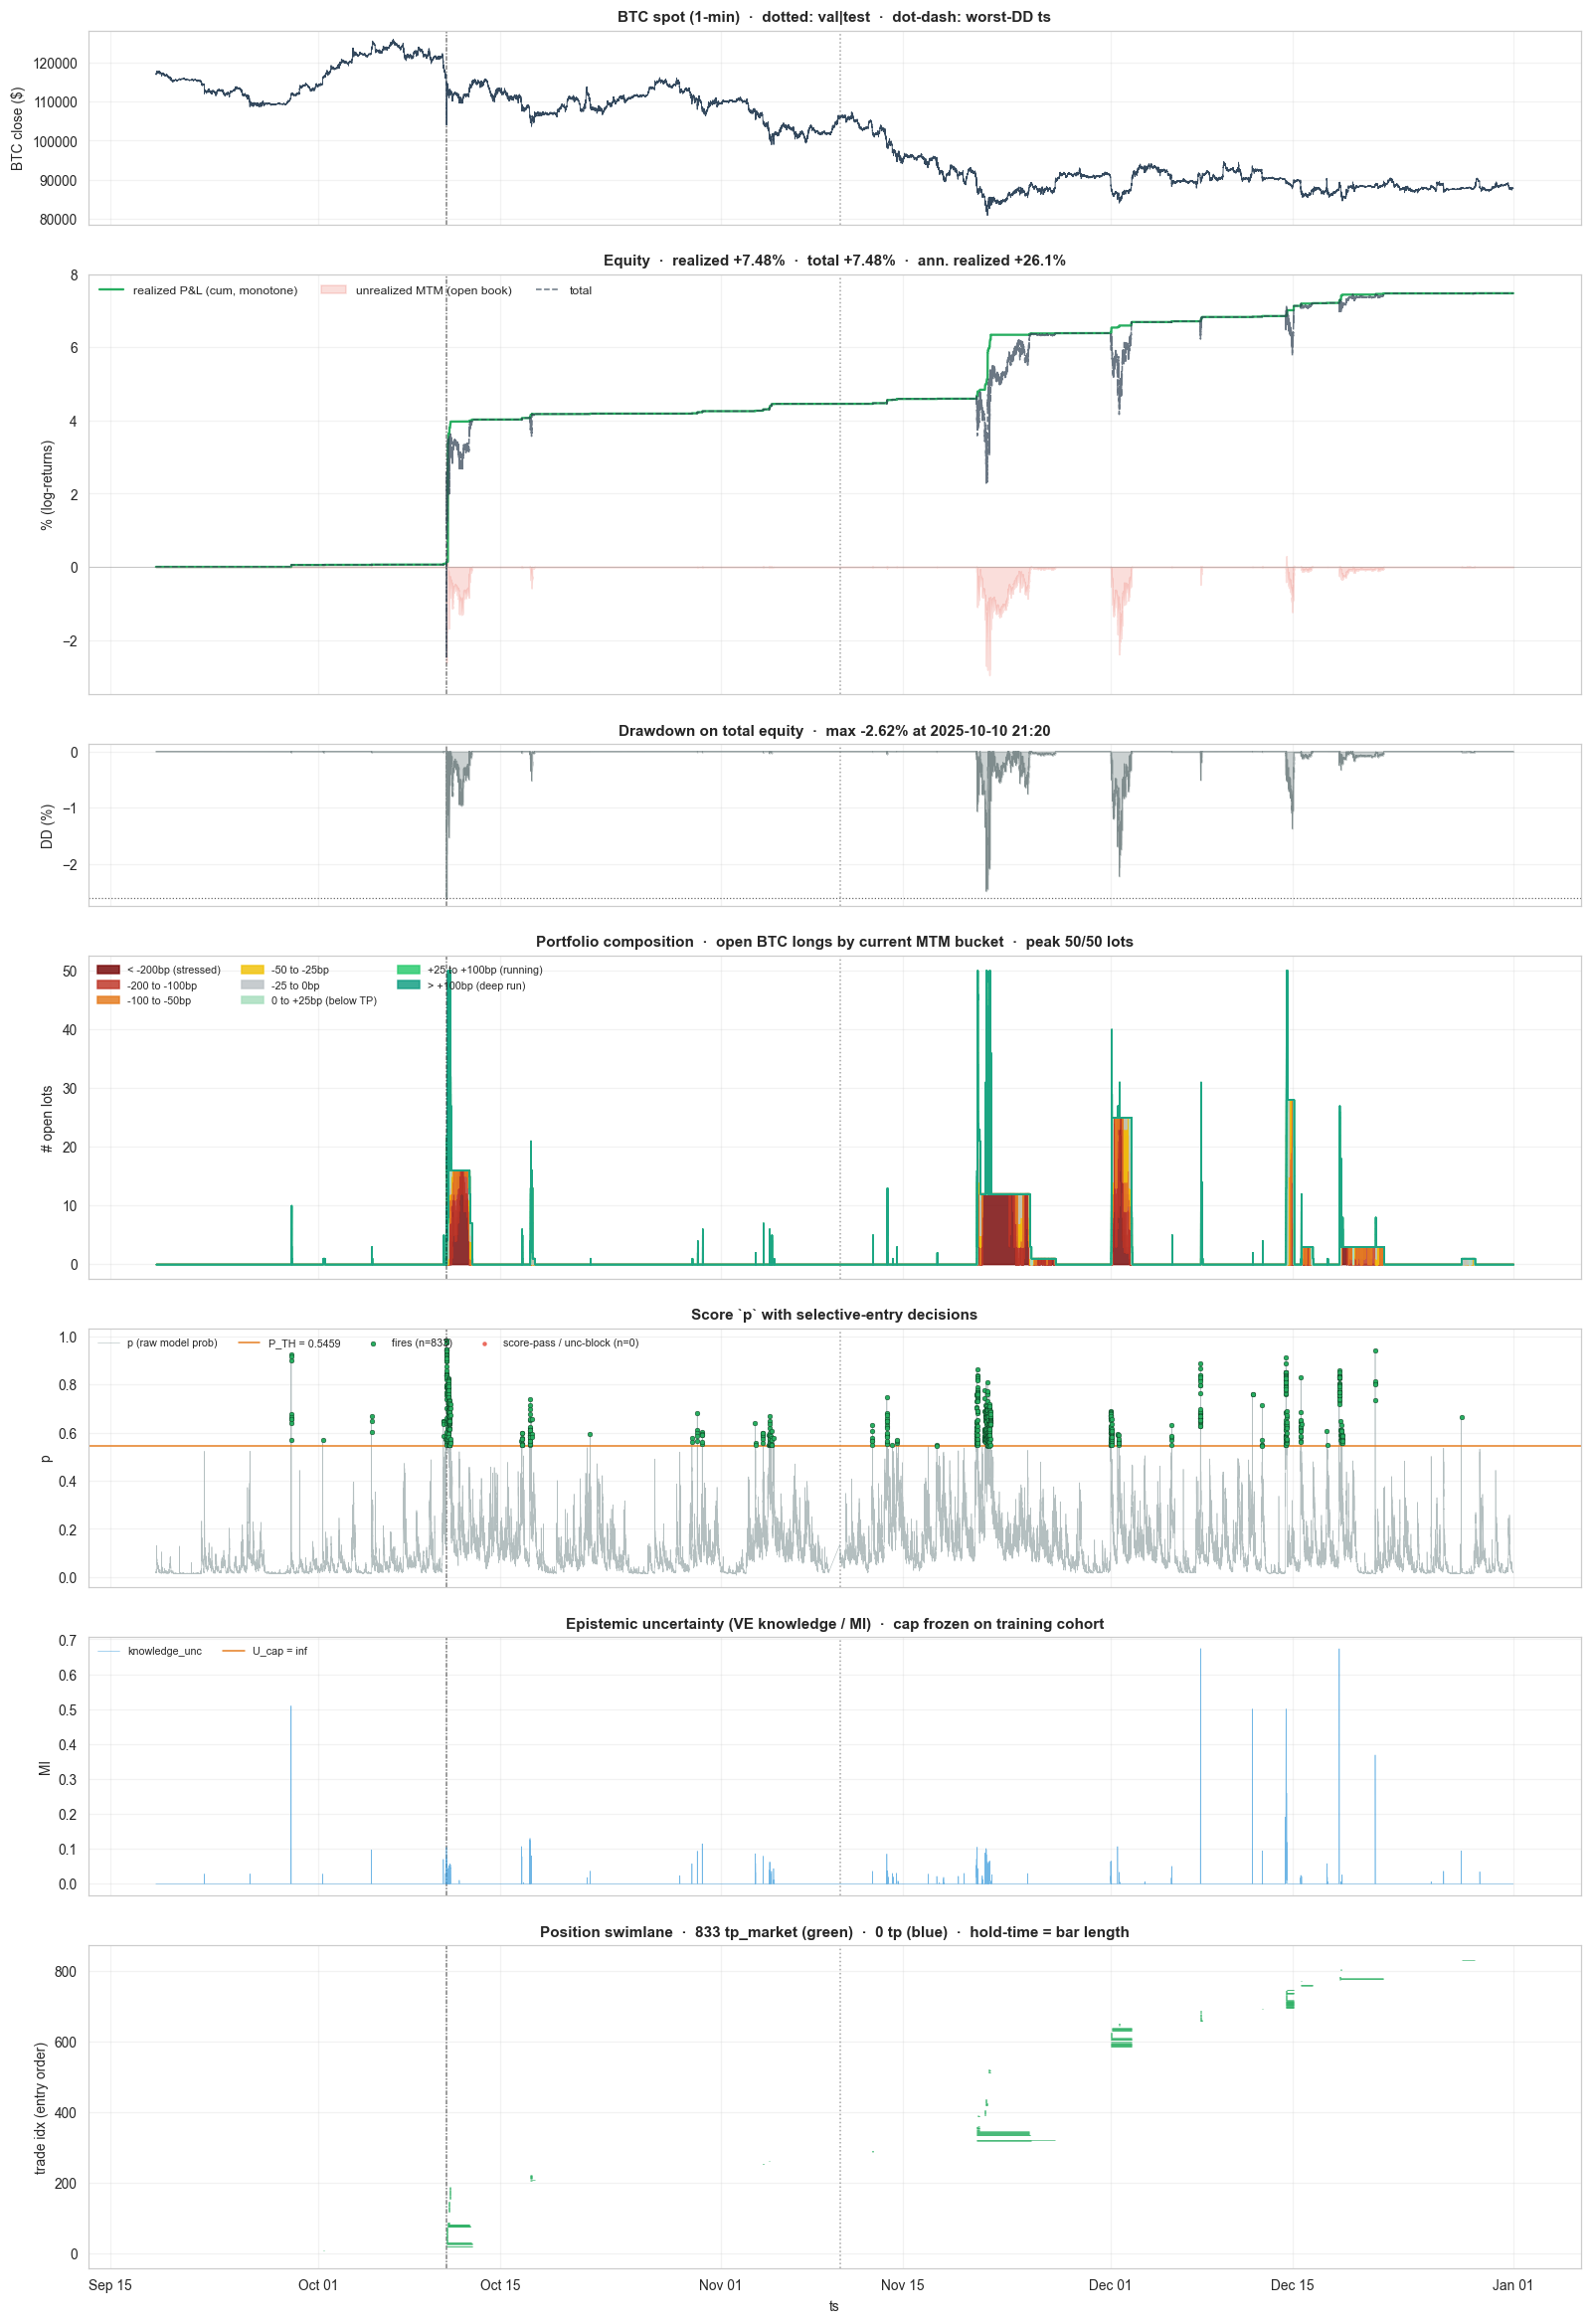

Saved: C:\Users\vitil\OneDrive\Desktop\barrier_classifier\data\model_dataset\strategy\production_1min_P1P3\dashboard.png


In [7]:
# ---- DASHBOARD: 7-panel time-aligned stack ------------------------------
fig = plt.figure(figsize=(15, 22))
gs = gridspec.GridSpec(
    nrows=7, ncols=1, figure=fig,
    height_ratios=[1.2, 2.6, 1.0, 2.0, 1.6, 1.6, 2.0],
    hspace=0.18, top=0.97, bottom=0.04, left=0.06, right=0.97,
)
ax_btc   = fig.add_subplot(gs[0])
ax_eq    = fig.add_subplot(gs[1], sharex=ax_btc)
ax_dd    = fig.add_subplot(gs[2], sharex=ax_btc)
ax_comp  = fig.add_subplot(gs[3], sharex=ax_btc)
ax_score = fig.add_subplot(gs[4], sharex=ax_btc)
ax_unc   = fig.add_subplot(gs[5], sharex=ax_btc)
ax_swim  = fig.add_subplot(gs[6], sharex=ax_btc)
all_axes = [ax_btc, ax_eq, ax_dd, ax_comp, ax_score, ax_unc, ax_swim]
for a in all_axes:
    a.axvline(val_test_boundary, color='gray', linestyle=':', linewidth=1, alpha=0.7)
    a.axvline(worst_dd_ts, color='black', linestyle=(0, (3, 1, 1, 1)), linewidth=1, alpha=0.5)

ax_btc.plot(btc_idx, btc_slice.values, color='#34495e', linewidth=0.6)
ax_btc.set_ylabel('BTC close ($)')
ax_btc.set_title('BTC spot (1-min)  ·  dotted: val|test  ·  dot-dash: worst-DD ts')

realized = eq['realized_cum'].to_numpy() * 100
unreal = eq['unrealized'].to_numpy() * 100
total = realized + unreal
ax_eq.plot(eq['ts'], realized, color='#27ae60', linewidth=1.5, label='realized P&L (cum, monotone)')
ax_eq.fill_between(eq['ts'], 0, unreal, color='#e74c3c', alpha=0.18, label='unrealized MTM (open book)')
ax_eq.plot(eq['ts'], total, color='#2c3e50', linestyle='--', linewidth=1.0, alpha=0.7, label='total')
ax_eq.axhline(0, color='gray', linewidth=0.5, alpha=0.5)
ax_eq.set_ylabel('% (log-returns)')
ax_eq.set_title(f"Equity  ·  realized {realized[-1]:+.2f}%  ·  total {total[-1]:+.2f}%  ·  ann. realized {annualized_realized*100:+.1f}%")
ax_eq.legend(loc='upper left', ncol=3, frameon=False)

dd_pct = dd_series * 100
ax_dd.fill_between(eq['ts'], 0, dd_pct, color='#7f8c8d', alpha=0.4)
ax_dd.plot(eq['ts'], dd_pct, color='#7f8c8d', linewidth=0.5)
ax_dd.axhline(-max_paper_dd*100, color='black', linestyle=':', linewidth=0.8, alpha=0.6)
ax_dd.set_ylabel('DD (%)')
ax_dd.set_title(f"Drawdown on total equity  ·  max {-max_paper_dd*100:.2f}% at {worst_dd_ts.strftime('%Y-%m-%d %H:%M')}")

ts_arr = eq['ts'].values
bottom = np.zeros(len(eq))
for b in range(len(BIN_LABELS)):
    ax_comp.fill_between(ts_arr, bottom, bottom + counts[:, b],
                         color=BIN_COLORS[b], alpha=0.85, label=BIN_LABELS[b], step='post')
    bottom = bottom + counts[:, b]
ax_comp.set_ylabel('# open lots')
ax_comp.set_title(f"Portfolio composition  ·  open BTC longs by current MTM bucket  ·  peak {peak_concurrent}/{MAX_CONCURRENT} lots")
ax_comp.legend(loc='upper left', ncol=3, frameon=False, fontsize=7)

ax_score.plot(eq['ts'], eq['p'], color='#95a5a6', linewidth=0.4, alpha=0.7, label='p (raw model prob)')
ax_score.axhline(P_TH, color='#e67e22', linestyle='-', linewidth=1.0, label=f'P_TH = {P_TH:.4f}')
fired = eq[eq['opened_this_step'].astype(bool)]
ax_score.scatter(fired['ts'], fired['p'], s=10, color='#27ae60', edgecolor='black', linewidth=0.2, zorder=3, label=f'fires (n={len(fired)})')
blocked = eq[(eq['p'] >= P_TH) & (eq['knowledge_unc'] > U_cap) & (~eq['opened_this_step'].astype(bool))]
ax_score.scatter(blocked['ts'], blocked['p'], s=4, color='#e74c3c', alpha=0.7, zorder=2, label=f'score-pass / unc-block (n={len(blocked)})')
ax_score.set_ylabel('p')
ax_score.set_title('Score `p` with selective-entry decisions')
ax_score.legend(loc='upper left', ncol=4, frameon=False, fontsize=7)

ax_unc.plot(eq['ts'], eq['knowledge_unc'], color='#3498db', linewidth=0.4, alpha=0.7, label='knowledge_unc')
ax_unc.axhline(U_cap, color='#e67e22', linestyle='-', linewidth=1.0, label=f'U_cap = {U_cap:.5f}')
ax_unc.set_ylabel('MI')
ax_unc.set_title('Epistemic uncertainty (VE knowledge / MI)  ·  cap frozen on training cohort')
ax_unc.legend(loc='upper left', ncol=2, frameon=False, fontsize=7)

if len(closed) > 0:
    closed_sorted = closed.sort_values('ts_entry').reset_index(drop=True)
    for i, tr in closed_sorted.iterrows():
        if tr['exit_reason'] == 'tp_market':
            color = '#27ae60'   # let-winners-run market exit
        elif tr['exit_reason'] == 'tp':
            color = '#3498db'   # static TP fill
        elif tr['exit_reason'] == 'sl':
            color = '#e74c3c'   # stop loss
        else:
            color = '#bdc3c7'   # expiry / other
        ax_swim.hlines(i, tr['ts_entry'], tr['ts_exit'], color=color, alpha=0.65, linewidth=0.6)
ax_swim.set_ylabel('trade idx (entry order)')
n_tp_mkt = int((result.closed['exit_reason']=='tp_market').sum()) if len(result.closed) else 0
n_tp = int((result.closed['exit_reason']=='tp').sum()) if len(result.closed) else 0
ax_swim.set_title(f"Position swimlane  ·  {n_tp_mkt} tp_market (green)  ·  {n_tp} tp (blue)  ·  hold-time = bar length")
ax_swim.set_xlabel('ts')

for a in all_axes[:-1]:
    plt.setp(a.get_xticklabels(), visible=False)
ax_swim.xaxis.set_major_locator(mdates.AutoDateLocator(maxticks=10))
ax_swim.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))

fig.savefig(OUT_DIR / 'dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {OUT_DIR / 'dashboard.png'}")


## 6. Trade-window zoom-ins — are entries at local minima?

Grid of 16 trades, each showing raw 1-min close ±60 min around entry,
entry & TP fill markers, and the TP target line. Samples: 4 fastest, 4
slowest, 4 deepest worst-MTM before recovering, 4 random.


In [8]:
def _select_trade_sample(closed_df, n_per_group=4, seed=0):
    if len(closed_df) == 0:
        return closed_df
    df = closed_df.copy()
    df['hold_min'] = (df['ts_exit'] - df['ts_entry']).dt.total_seconds() / 60.0
    raw_idx_local = raw_bars.index
    raw_low_arr = raw_bars['low'].to_numpy()
    worst = np.zeros(len(df))
    for i, (_, tr) in enumerate(df.iterrows()):
        lo = int(np.searchsorted(raw_idx_local, np.datetime64(tr['ts_entry']), side='right'))
        hi = int(np.searchsorted(raw_idx_local, np.datetime64(tr['ts_exit']), side='right'))
        if hi > lo:
            worst[i] = float(np.log(raw_low_arr[lo:hi].min() / tr['entry_price']))
    df['worst_mtm'] = worst
    fastest = df.nsmallest(n_per_group, 'hold_min')
    slowest = df.nlargest(n_per_group, 'hold_min')
    deepest = df.nsmallest(n_per_group, 'worst_mtm')
    rng = np.random.default_rng(seed)
    random_idx = rng.choice(df.index, size=min(n_per_group, len(df)), replace=False)
    randoms = df.loc[random_idx]
    selected = pd.concat([fastest, slowest, deepest, randoms]).drop_duplicates(subset=['ts_entry']).reset_index(drop=True)
    selected['group'] = (
        ['fastest']*len(fastest) + ['slowest']*len(slowest) + ['worst-MTM']*len(deepest) + ['random']*len(randoms)
    )[:len(selected)]
    return selected

def _entry_local_min_rank(closed_df, raw_bars_df, *, window_minutes=60):
    if len(closed_df) == 0:
        return np.array([])
    raw_idx_local = raw_bars_df.index
    raw_close_arr = raw_bars_df['close'].to_numpy()
    ranks = np.full(len(closed_df), np.nan)
    for i, (_, tr) in enumerate(closed_df.iterrows()):
        ts_entry = pd.Timestamp(tr['ts_entry'])
        i0 = int(np.searchsorted(raw_idx_local, np.datetime64(ts_entry - pd.Timedelta(minutes=window_minutes)), side='left'))
        i1 = int(np.searchsorted(raw_idx_local, np.datetime64(ts_entry + pd.Timedelta(minutes=window_minutes)), side='right'))
        if i1 <= i0 + 1:
            continue
        window = raw_close_arr[i0:i1]
        ep = float(tr['entry_price'])
        rank = float((window < ep).sum()) / float(len(window) - 1)
        ranks[i] = rank
    return ranks

sample = _select_trade_sample(closed, n_per_group=4) if len(closed) else closed
print(f"Selected {len(sample)} trades for zoom-in inspection")
if len(closed):
    closed['local_min_rank'] = _entry_local_min_rank(closed, raw_bars, window_minutes=60)
    sample['local_min_rank'] = _entry_local_min_rank(sample, raw_bars, window_minutes=60)


Selected 16 trades for zoom-in inspection


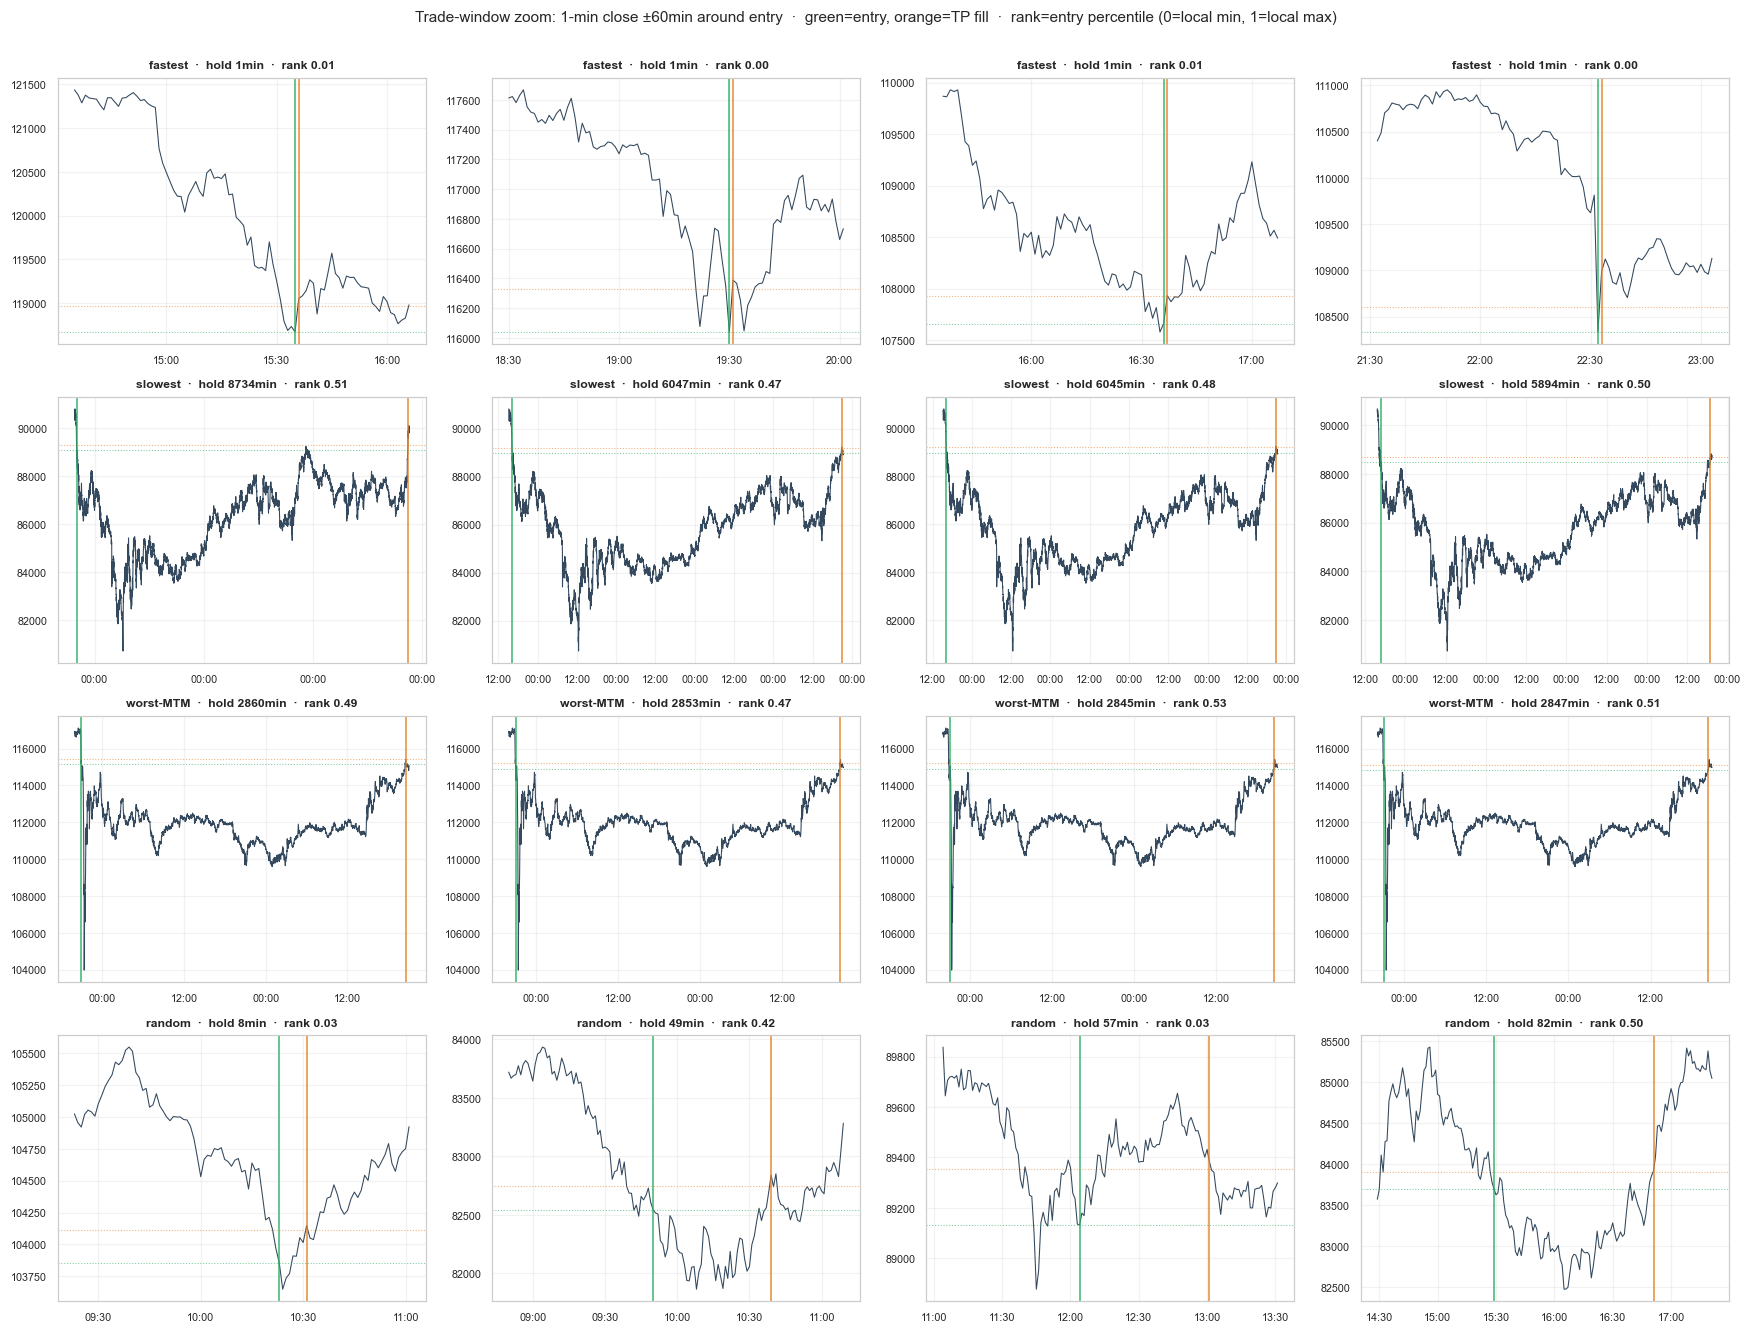

Saved: C:\Users\vitil\OneDrive\Desktop\barrier_classifier\data\model_dataset\strategy\production_1min_P1P3\trade_zoom_grid.png


In [9]:
if len(sample) > 0:
    n_rows, n_cols = 4, 4
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 12), sharey=False)
    raw_idx_local = raw_bars.index
    raw_close_arr = raw_bars['close'].to_numpy()
    for ax, (_, tr) in zip(axes.flat, sample.iterrows()):
        ts_in = pd.Timestamp(tr['ts_entry'])
        ts_out = pd.Timestamp(tr['ts_exit'])
        t0 = ts_in - pd.Timedelta(minutes=60)
        t1 = ts_out + pd.Timedelta(minutes=30)
        i0 = int(np.searchsorted(raw_idx_local, np.datetime64(t0), side='left'))
        i1 = int(np.searchsorted(raw_idx_local, np.datetime64(t1), side='right'))
        if i1 <= i0:
            ax.axis('off'); continue
        win_idx = raw_idx_local[i0:i1]
        win_close = raw_close_arr[i0:i1]
        ax.plot(win_idx, win_close, color='#34495e', linewidth=0.7)
        ax.axvline(ts_in, color='#27ae60', linewidth=1.0, alpha=0.9)
        ax.axvline(ts_out, color='#e67e22', linewidth=1.0, alpha=0.9)
        ax.axhline(float(tr['entry_price']), color='#27ae60', linestyle=':', linewidth=0.7, alpha=0.6)
        ax.axhline(float(tr['tp_price']), color='#e67e22', linestyle=':', linewidth=0.7, alpha=0.6)
        hold_min = (ts_out - ts_in).total_seconds() / 60.0
        ax.set_title(f"{tr.get('group','?')}  ·  hold {hold_min:.0f}min  ·  rank {tr.get('local_min_rank', np.nan):.2f}", fontsize=8)
        ax.tick_params(axis='x', rotation=0, labelsize=7)
        ax.tick_params(axis='y', labelsize=7)
        ax.xaxis.set_major_locator(mdates.AutoDateLocator(maxticks=4))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    plt.suptitle(
        'Trade-window zoom: 1-min close ±60min around entry  ·  green=entry, orange=TP fill  ·  rank=entry percentile (0=local min, 1=local max)',
        y=1.005, fontsize=10,
    )
    plt.tight_layout()
    fig.savefig(OUT_DIR / 'trade_zoom_grid.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {OUT_DIR / 'trade_zoom_grid.png'}")


## 7. Local-minimum-rank distribution (aggregate)

For every closed trade, rank the entry price within a ±60-minute window
around the entry. 0 = local min; 1 = local max. If the strategy is buying
dips, this should skew toward 0.


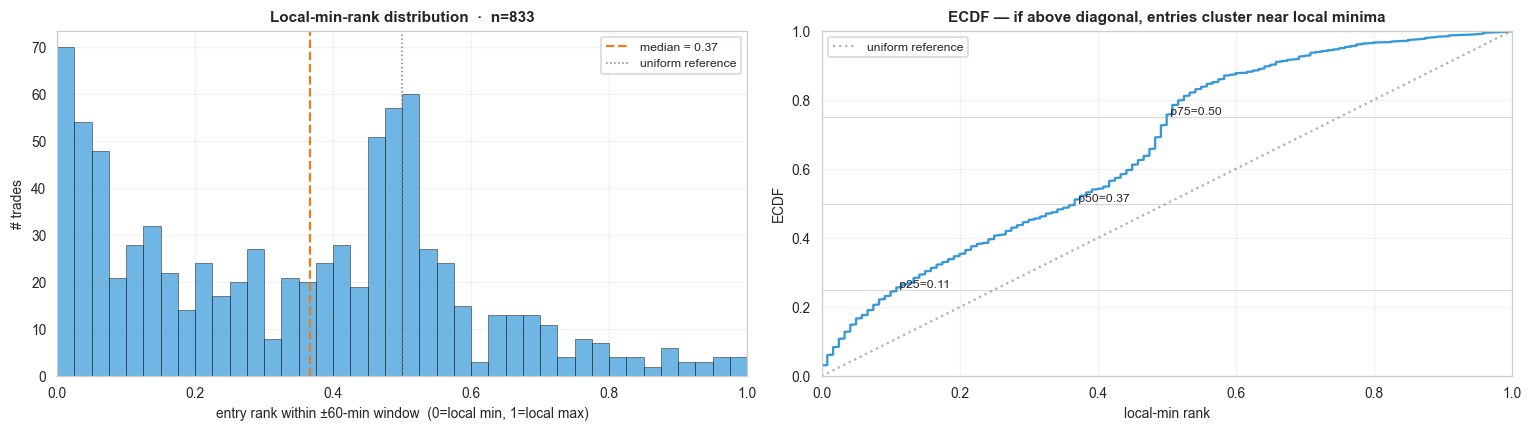

Saved: C:\Users\vitil\OneDrive\Desktop\barrier_classifier\data\model_dataset\strategy\production_1min_P1P3\local_min_rank.png
median=0.37  mean=0.34  frac<0.5=72.63%


In [10]:
if len(closed):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    ranks = closed['local_min_rank'].dropna().to_numpy()

    axes[0].hist(ranks, bins=40, color='#3498db', alpha=0.7, edgecolor='black', linewidth=0.4)
    axes[0].axvline(np.median(ranks), color='#e67e22', linestyle='--', linewidth=1.5, label=f'median = {np.median(ranks):.2f}')
    axes[0].axvline(0.5, color='gray', linestyle=':', linewidth=1.0, label='uniform reference')
    axes[0].set_xlabel('entry rank within ±60-min window  (0=local min, 1=local max)')
    axes[0].set_ylabel('# trades')
    axes[0].set_title(f'Local-min-rank distribution  ·  n={len(ranks)}')
    axes[0].legend(); axes[0].set_xlim(0, 1)

    sorted_r = np.sort(ranks)
    ecdf = np.arange(1, len(sorted_r)+1) / len(sorted_r)
    axes[1].plot(sorted_r, ecdf, color='#3498db')
    axes[1].plot([0, 1], [0, 1], color='gray', linestyle=':', alpha=0.6, label='uniform reference')
    for q in [0.25, 0.5, 0.75]:
        v = float(np.quantile(ranks, q))
        axes[1].axhline(q, color='gray', linewidth=0.4, alpha=0.5)
        axes[1].text(v, q, f' p{int(q*100)}={v:.2f}', fontsize=8, va='bottom')
    axes[1].set_xlabel('local-min rank'); axes[1].set_ylabel('ECDF')
    axes[1].set_title('ECDF — if above diagonal, entries cluster near local minima')
    axes[1].legend(); axes[1].set_xlim(0, 1); axes[1].set_ylim(0, 1)

    plt.tight_layout()
    fig.savefig(OUT_DIR / 'local_min_rank.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {OUT_DIR / 'local_min_rank.png'}")

    rank_summary = {
        'n_trades': int(len(ranks)),
        'median': float(np.median(ranks)),
        'mean': float(np.mean(ranks)),
        'p25': float(np.quantile(ranks, 0.25)),
        'p75': float(np.quantile(ranks, 0.75)),
        'frac_below_0.25': float((ranks < 0.25).mean()),
        'frac_below_0.5': float((ranks < 0.5).mean()),
        'window_minutes': 60,
    }
    with open(OUT_DIR / 'local_min_rank_summary.json', 'w') as f:
        json.dump(rank_summary, f, indent=2)
    print(f"median={rank_summary['median']:.2f}  mean={rank_summary['mean']:.2f}  frac<0.5={rank_summary['frac_below_0.5']:.2%}")


## 8. Post-hoc characterization — hold-time and worst-MTM-per-position

Two distributions a live operator should be sized against. Both peek at
future paths; characterization, not decisions.


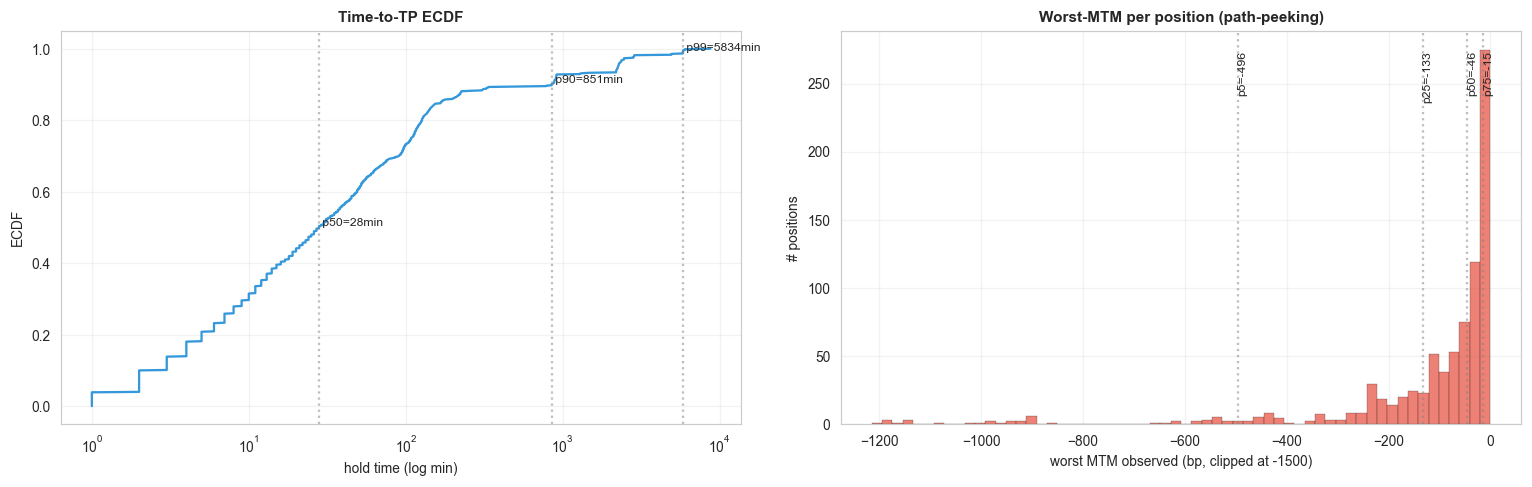

Saved: C:\Users\vitil\OneDrive\Desktop\barrier_classifier\data\model_dataset\strategy\production_1min_P1P3\hold_and_worst_mtm.png
Saved: C:\Users\vitil\OneDrive\Desktop\barrier_classifier\data\model_dataset\strategy\production_1min_P1P3\closed_trades.parquet (833 rows)


In [11]:
if len(closed):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
    closed['hold_minutes'] = (closed['ts_exit'] - closed['ts_entry']).dt.total_seconds() / 60.0

    sorted_h = np.sort(closed['hold_minutes'].to_numpy())
    ecdf = np.arange(1, len(sorted_h)+1) / len(sorted_h)
    axes[0].semilogx(sorted_h, ecdf, color='#3498db')
    for q, lab in [(0.50, 'p50'), (0.90, 'p90'), (0.99, 'p99')]:
        v = float(np.quantile(closed['hold_minutes'], q))
        axes[0].axvline(v, color='gray', linestyle=':', alpha=0.5)
        axes[0].text(v, q, f' {lab}={v:.0f}min', verticalalignment='bottom', fontsize=8)
    axes[0].set_xlabel('hold time (log min)'); axes[0].set_ylabel('ECDF')
    axes[0].set_title('Time-to-TP ECDF')

    raw_idx_local = raw_bars.index
    raw_low_arr = raw_bars['low'].to_numpy()
    worst = []
    for _, row in closed.iterrows():
        lo = int(np.searchsorted(raw_idx_local, np.datetime64(row['ts_entry']), side='right'))
        hi = int(np.searchsorted(raw_idx_local, np.datetime64(row['ts_exit']), side='right'))
        if hi <= lo:
            worst.append(0.0); continue
        worst.append(float(np.log(raw_low_arr[lo:hi].min() / row['entry_price'])))
    closed['worst_mtm_bp'] = np.asarray(worst) * 10000.0
    axes[1].hist(closed['worst_mtm_bp'].clip(lower=-1500, upper=0), bins=60,
                 color='#e74c3c', alpha=0.7, edgecolor='black', linewidth=0.2)
    for q in [0.05, 0.25, 0.50, 0.75]:
        v = float(closed['worst_mtm_bp'].quantile(q))
        axes[1].axvline(v, color='gray', linestyle=':', alpha=0.5)
        axes[1].text(v, axes[1].get_ylim()[1]*0.95, f'p{int(q*100)}={v:.0f}', rotation=90, va='top', fontsize=8)
    axes[1].set_xlabel('worst MTM observed (bp, clipped at -1500)')
    axes[1].set_ylabel('# positions')
    axes[1].set_title('Worst-MTM per position (path-peeking)')

    plt.tight_layout()
    fig.savefig(OUT_DIR / 'hold_and_worst_mtm.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {OUT_DIR / 'hold_and_worst_mtm.png'}")

    closed.to_parquet(OUT_DIR / 'closed_trades.parquet', index=False)
    print(f"Saved: {OUT_DIR / 'closed_trades.parquet'} ({len(closed):,} rows)")


## 9. Sensitivity to `UNC_Q_COND`

Re-run across a small grid of conditional-quantile choices. Smaller q =
stricter epistemic filter, fewer trades. Shows whether tightening the
unc gate trades volume for quality.


In [12]:
rows = []
for q in [0.25, 0.40, 0.50, 0.65, 0.80, 1.00]:
    u_cap = derive_conditional_unc_cap(p_train, unc_train, p_threshold=P_TH, q=q)
    sp = StrategySpec(
        name=f'sweep_unc_q_{q}',
        requires=('ve_diag',),
        score_fn=score_raw_p,
        entry_gates=(
            lambda s, t=P_TH: gate_score_above(s, t),
            lambda s, c=u_cap: gate_knowledge_unc_cap(s, c),
        ),
        sizer=lambda s, sz=LOT_SIZE: size_clip(size_constant(s, default=sz), max_size=1.0),
        exit_policy=make_exit_let_winners_run(p_map, hold_threshold=P_TH, sl_log_return=None),
        bulk_close=lambda s: None,
        risk=RiskConfig(
            cost_per_trade=COST,
            max_open_positions=MAX_CONCURRENT,
            max_gross_size=MAX_CONCURRENT * LOT_SIZE + 1e-6,
            max_horizon_boundaries=MAX_HORIZON_BOUNDARIES,
        ),
    )
    rr = simulate(sim_cache, raw_bars, sp, config=cfg)
    n_sig = int(rr.equity['opened_this_step'].sum())
    n_tp = int((rr.closed['exit_reason']=='tp').sum()) if len(rr.closed) else 0
    realized_pct = float(rr.equity['realized_cum'].iloc[-1]) * 100
    min_unreal_pct = float(rr.equity['unrealized'].min()) * 100
    rows.append({
        'unc_q': q, 'U_cap_bp': u_cap * 1e4,
        'signals': n_sig, 'TPs': n_tp, 'open_at_end': int(rr.equity['n_open'].iloc[-1]),
        'realized_pct': realized_pct, 'min_unrealized_pct': min_unreal_pct,
    })
sweep_df = pd.DataFrame(rows)
display(sweep_df.style.format({
    'U_cap_bp': '{:.4f}', 'realized_pct': '{:+.3f}', 'min_unrealized_pct': '{:+.3f}',
}).hide(axis='index'))
sweep_df.to_csv(OUT_DIR / 'unc_q_sweep.csv', index=False)
print(f"Saved: {OUT_DIR / 'unc_q_sweep.csv'}")


unc_q,U_cap_bp,signals,TPs,open_at_end,realized_pct,min_unrealized_pct
0.250000,16.4424,137,0,0,+3.675,-1.037
0.400000,46.6771,231,0,0,+4.191,-1.037
0.500000,84.3992,293,0,0,+4.711,-1.046
0.650000,174.0687,432,0,0,+5.614,-1.728
0.800000,428.9874,562,0,0,+6.334,-2.828
1.000000,6931.4718,833,0,0,+7.479,-2.961


Saved: C:\Users\vitil\OneDrive\Desktop\barrier_classifier\data\model_dataset\strategy\production_1min_P1P3\unc_q_sweep.csv


## 10. Closing notes

**Claims**
- Gate uses threshold *frozen on training data only*. Val/test never
  influenced the strategy's parameters.
- The simulator is bit-equivalent to a live operator who places a market
  sell the first bar after entry where the model's `p_t < P_TH` AND
  the bar's high has crossed the +phi target.
- Strategy never closes at a loss: no SL, no bulk-close, no horizon. If
  conviction drops while the position is *below* the TP target, the
  position waits.

**Limits**
- The training-period HPO leak from notebook 03 still applies — the gate
  threshold is frozen on train, but the model itself wasn't trained
  under nested CV. Separate piece of work.
- No walk-forward refresh of `P_TH`. In production this should be
  re-derived monthly from the trailing training-period score distribution.
- The strategy is **structurally long-biased**, not delta-neutral. Realized
  P&L can be positive in a falling market only because individual lots
  hold until the model's conviction at the +phi touch drops. In a sharp,
  fast bear that breaks intra-bar volatility patterns, holds can extend
  for days waiting for re-entry into the TP zone.

**Provenance**
- Derived from the strategy-variants sweep on the post-P2 model:
  `scripts/run_strategy_variants.py`, summary at
  `data/model_dataset/strategy/variants/comparison_summary.json`.